In [12]:
from amplpy import AMPL, OutputHandler, Kind
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [3]:
"""
Simulates forecast error using a uniform random variable

Takes list of dictionaries for prices
Returns list of dictionaries for forecasted prices
"""
def simulate_forecast_error(rt_prices, rt_percent_error, da_prices, da_percent_error):
    forecasted_rt_prices = []
    forecasted_da_prices = []
    for day in range(len(rt_prices)):
        daily_rt_prices = list(rt_prices[day].values())
        daily_forecasted_rt_prices = daily_rt_prices + daily_rt_prices * np.random.uniform(-rt_percent_error, rt_percent_error, size=len(daily_rt_prices))
        forecasted_rt_prices.append(dict(zip(rt_prices[day].keys(), daily_forecasted_rt_prices.astype(float).tolist())))
        daily_da_prices = list(da_prices[day].values())
        daily_forecasted_da__prices = daily_da_prices + daily_da_prices * np.random.uniform(-da_percent_error, da_percent_error, size=len(daily_da_prices))
        forecasted_da_prices.append(dict(zip(da_prices[day].keys(), daily_forecasted_da__prices.astype(float).tolist())))
    return forecasted_rt_prices, forecasted_da_prices

In [4]:
""" 
Generates BESS charge and dishcarge schedule based on forecasted prices and evaluates total profit under the actual prices.

Takes list of dictionaries for prices
Returns total profit over the simulation horizon
"""
# TODO: Fix reavaluation glitch
def run_optimization(ampl, dynamic_params, da_prices, rt_prices, forecasted_da_prices, forecasted_rt_prices):
    total_profit = 0
    for day in range(len(rt_prices)):
        # Solve for a single day with forecasted prices
        ampl.param['Pi_DA_E'] = forecasted_da_prices[day]
        ampl.param['Pi_RT_E'] = forecasted_rt_prices[day]
        ampl.solve()
        
        # Update prices to reflect actual prices observed on the day
        ampl.param['Pi_DA_E'] = da_prices[day]
        ampl.param['Pi_RT_E'] = rt_prices[day]

        # Evaluate objective function for actual prices
        total_profit += ampl.get_objective('Total_Profit').value()

        # ampl.param['SOC_0'] = round(list(ampl.get_variable('soc').to_dict().values())[-1], 1)
        # ampl.param['P_CH_0'] = round(list(ampl.get_variable('pch_RT').to_dict().values())[-1], 1)
        # ampl.param['P_G_0'] = round(list(ampl.get_variable('pg_RT').to_dict().values())[-1], 1)

    # reset parameters
    # for name, value in dynamic_params.items():
    #     ampl.param[name] = value

    return total_profit


In [5]:
"""
Runs sensitivity analysis for arbitrage profit by perfoming monte carlo simulation using forecasted prices at a variety of error margins

Takes optimization model, prices as list of dictionaries, and array of values for forcast percent errors
Returns average, standard deviation, and percent profit lost due to forecast errors
"""
def run_sensitivity_test(ampl, dynamic_params, da_prices, rt_prices, T, percent_errors, filename='output.xlsx'):
    optimum = run_optimization(ampl, dynamic_params, da_prices, rt_prices, da_prices, rt_prices)
    mean_loss = pd.DataFrame(np.nan, index=percent_errors, columns=percent_errors)
    std_loss = pd.DataFrame(np.nan, index=percent_errors, columns=percent_errors)
    # percent_loss = pd.DataFrame(np.nan, index=percent_errors, columns=percent_errors)
    maximum_regret = pd.DataFrame(np.nan, index=percent_errors, columns=percent_errors)
    # max_percent_regret = pd.DataFrame(np.nan, index=percent_errors, columns=percent_errors)
    total_iterations = len(percent_errors)**2 * T
    with tqdm(total=total_iterations, desc="Total Progress") as pbar:
        for da_err in percent_errors:
            for rt_err in percent_errors:
                total_profits = []
                for _ in range(T):
                    forecasted_rt_prices, forecasted_da_prices = simulate_forecast_error(rt_prices, rt_err, da_prices, da_err)
                    total_profit = run_optimization(ampl, dynamic_params, da_prices, rt_prices, forecasted_da_prices, forecasted_rt_prices)
                    total_profits.append(total_profit)
                    pbar.update(1)
                total_profits_arr = np.array(total_profits)
                regret = optimum - total_profits_arr
                mean_loss.loc[da_err, rt_err] = np.mean(regret)
                std_loss.loc[da_err, rt_err] = np.std(regret)
                # percent_loss.loc[da_err, rt_err] = np.mean(optimum - total_profits_arr) / optimum
                maximum_regret.loc[da_err, rt_err] = max(regret)
                # max_percent_regret.loc[da_err, rt_err] = max(optimum - total_profits_arr) / optimum
        
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        mean_loss.to_excel(writer, sheet_name='Mean Regret')
        std_loss.to_excel(writer, sheet_name='Standard Deviation of Regret')
        # percent_loss.to_excel(writer, sheet_name='Percent Mean Regret')
        maximum_regret.to_excel(writer, sheet_name='Maximum Regret')
        # max_percent_regret.to_excel(writer, sheet_name='Percent Max Regret')
        pd.DataFrame({"Summary":[optimum, T]}, index=["Optimal Profit ($)", "Monte Carlo Simulations"]).to_excel(writer, sheet_name="Optimum")

    print(f"Optimal Value ${optimum:2f}")
    print()
    print("MEAN REGRET")       
    print(mean_loss)
    print()
    print("STD REGRET")
    print(std_loss)
    print()
    print("MAXIMUM REGRET")
    print(maximum_regret)


In [6]:
time_steps_per_hour = 4  # Number of time steps of real time data in each hour. Ex: 4 for 15-minutely real time prices
num_of_hours = 24 # Number of hours to solve for
time_steps = list(range(1, num_of_hours*time_steps_per_hour + 1))
hours = list(range(1, num_of_hours + 1))
map = [(h, t) for h in hours for t in time_steps if (h-1)*time_steps_per_hour < t <= h*time_steps_per_hour] # Map time steps to hours

In [7]:
class outputHandler(OutputHandler):
    def output(self, kind, msg):
        if kind == Kind.PROBLEM:
            print(msg)


# Load the model
ampl = AMPL()
ampl.read('arbitrage.mod')

# Set parameters
ampl.set['T'] = time_steps
ampl.set['H'] = hours
ampl.set['MAP'] = map

static_params = {
    'SOC_cap': 50,     # MWh
    'P_CH_max': 50,     # MW
    'P_G_max': 50,      # MW
    'eff_ch': 0.9329,
    'eff_g': 0.9326,
    # 'RUP': 50,          # MW/h
    # 'RDWN': 50,         # MW/h
    'num_t_per_hour': time_steps_per_hour,
    # 'SOC_T_limit': 0,  # MWh


}

dynamic_params = {
    'SOC_0': 0,        # MWh
    # 'P_CH_0': 0,
    # 'P_G_0': 0,
}
for name, value in static_params.items():
    ampl.param[name] = value

for name, value in dynamic_params.items():
    ampl.param[name] = value

# Set solver options
gurobi_settings = (
    "outlev=0 " 
    "threads=1 " 
    # "MIPFocus=3 "
    "mipgap=0.05 "
    # "timelim=2 "
    "warmstart=1"
)

ampl.set_output_handler(outputHandler())
ampl.set_option('solver_msg', 0)
ampl.set_option('display_output', 0)
ampl.set_option("solver", "gurobi")
ampl.set_option("gurobi_options", gurobi_settings)

In [8]:
def parse_DA_data(filepath):
    df = pd.read_csv(filepath)
    hours = [i for i in range(1, 25)]
    da_prices = []
    for i in range(0, len(df.index), 24):
        da_prices.append(dict(zip(hours, df['spp'][i:i+24])))
    return da_prices

In [9]:
def parse_RT_data(filepath):
    df = pd.read_csv(filepath)
    time_steps = [i for i in range(1, 97)]
    rt_prices = []
    for i in range(0, len(df.index), 96):
        rt_prices.append(dict(zip(time_steps, df['spp'][i:i+96])))
    return rt_prices

In [153]:
### RUN THIS CELL FOR FULL SIMULATION ####
da_prices = parse_DA_data('DA_PRICES_SBEAN_JUL.csv')[:2] 
rt_prices = parse_RT_data('RT_PRICES_SBEAN_JUL.csv')[:2] 
T = 3 # NUMBER OF MONTE CARLO SIMULATION
# percent_errors = list(np.linspace(0.05, 0.2, 2)) # PERCENT ERRORS
percent_errors = []
run_sensitivity_test(ampl, dynamic_params, da_prices, rt_prices, T, percent_errors)

Total Progress: 0it [00:00, ?it/s]

Optimal Value $15488.398967

MEAN REGRET
Empty DataFrame
Columns: []
Index: []

STD REGRET
Empty DataFrame
Columns: []
Index: []

MAXIMUM REGRET
Empty DataFrame
Columns: []
Index: []


In [11]:
# Retrieve results
total_profit = ampl.get_objective('Total_Profit').value()
print(f"Optimal Expected Profit: ${total_profit:.2f}")

Optimal Expected Profit: $6246.70


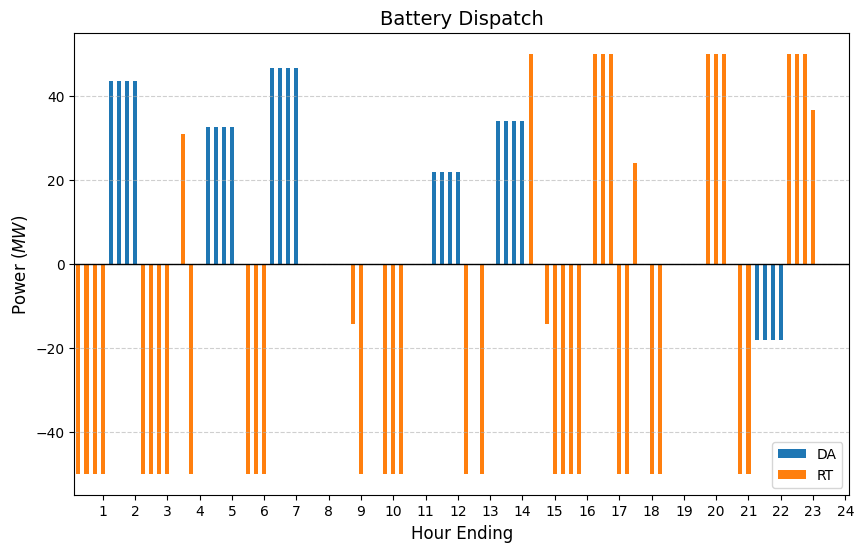

In [ ]:
pch_DA = [round(v, 1) for v in ampl.get_variable('pch_DA').to_dict().values()]
pg_DA = [round(v, 1) for v in ampl.get_variable('pg_DA').to_dict().values()]
dispatch_DA = []
for p, c in zip(pg_DA, pch_DA):
    dispatch_DA += [p - c] * time_steps_per_hour

pch_RT = [round(v,1) for v in ampl.get_variable('pch_RT').to_dict().values()]
pg_RT = [round(v,1) for v in ampl.get_variable('pg_RT').to_dict().values()]
dispatch_RT = [p - c - d for p, c, d in zip(pg_RT, pch_RT, dispatch_DA)]

times = [t/time_steps_per_hour for t in time_steps]
dispatch = pd.DataFrame({'Time': times, 'DA': dispatch_DA, 'RT': dispatch_RT}).set_index('Time')
ax = dispatch.plot(kind='bar', stacked=True, figsize=(10,6))

plt.axhline(0, color='black', linewidth=1)  # Bold the 0 line
plt.xlabel('Hour Ending', fontsize=12)
plt.ylabel('Power ($MW$)', fontsize=12)
plt.title('Battery Dispatch', fontsize=14)

ax.set_xticks(range(3, num_of_hours*time_steps_per_hour, time_steps_per_hour))  # Show hours on x-axis
ax.set_xticklabels(range(1, num_of_hours+1), rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

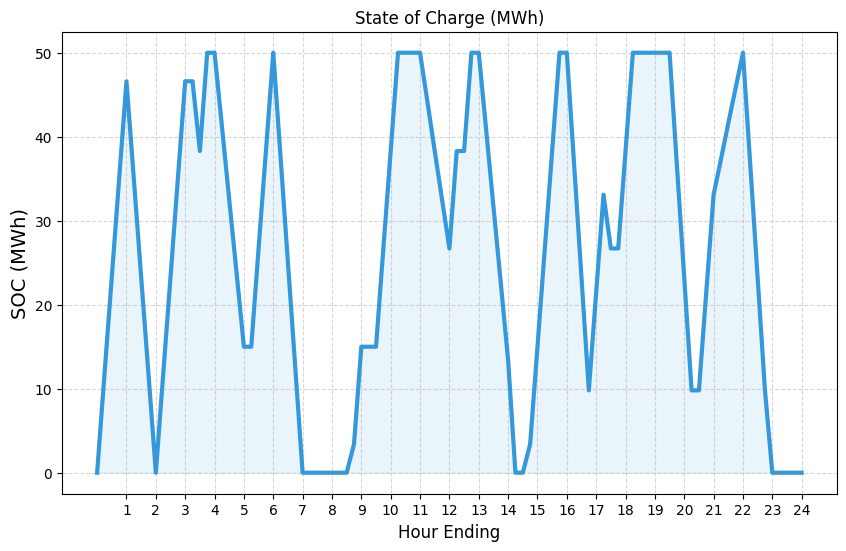

In [106]:
soc = [round(v, 1) for v in ampl.get_variable('soc').to_dict().values()]

# --- Figure 2: State of Charge (The "Effect") ---
plt.figure(figsize=(10, 6))
plt.plot([0] + times, soc, color='#3498db', linewidth=3)
plt.fill_between([0] + times, soc, color='#3498db', alpha=0.1)
plt.xlabel('Hour Ending', fontsize=12)
plt.ylabel('SOC (MWh)', fontsize=14)
plt.title('State of Charge (MWh)', fontsize=12)
plt.xticks(hours)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [37]:
# def parse_RT_data(filepath):
#     df = pd.read_csv(filepath)
#     return df['spp'][0:672].to_list()
# da_prices = parse_DA_data('DA_PRICES_SBEAN_JUL.csv')[:2] 
# rt_prices = parse_RT_data('RT_PRICES_SBEAN_JUL.csv')[:2] 
dam_prices = pd.read_csv('DA_PRICES_SBEAN_JUL.csv')['spp'][0:168].to_list()
rtm_prices = pd.read_csv('RT_PRICES_SBEAN_JUL.csv')['spp'][0:672].to_list()

In [38]:
print(len(dam_prices))
print(len(rtm_prices))

168
672


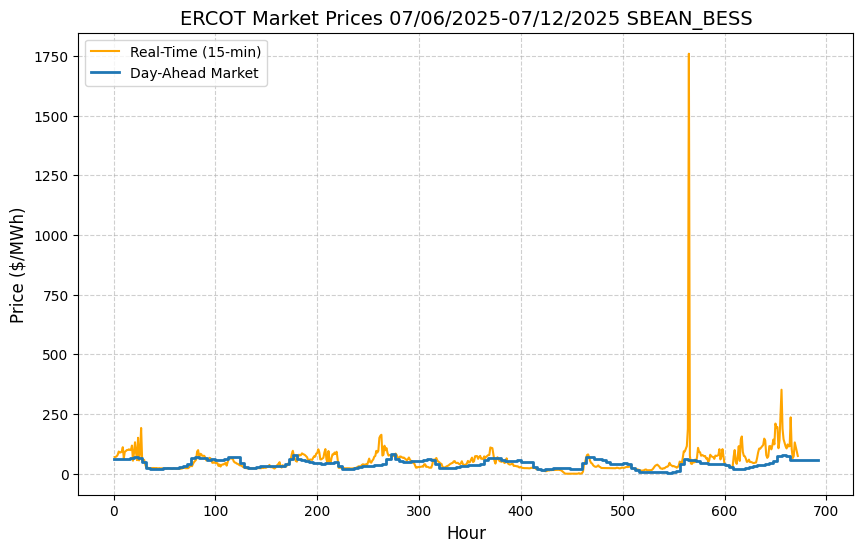

In [44]:
# dam_prices = da_prices[-1].values()
# rtm_prices = rt_prices[-1].values()

dam_prices = list(dam_prices) + list(dam_prices)[-1:]

plt.figure(figsize=(10, 6))

plt.plot(range(1, len(rtm_prices)+1), rtm_prices, label='Real-Time (15-min)', 
         color='orange', alpha=1, linewidth=1.5)

plt.step(range(0, len(dam_prices)*4, 4), dam_prices, where='post', label='Day-Ahead Market', linewidth=2)

# plt.xticks(range(4, 98, 4), labels=range(1, 25))
# 3. Formatting
plt.title('ERCOT Market Prices 07/06/2025-07/12/2025 SBEAN_BESS', fontsize=14)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Price ($/MWh)', fontsize=12)
# plt.ylim(-1, 375)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()

plt.show()

In [ ]:
def calculate_cum_profit(day_ahead_prices, real_time_prices, pch_DA, pg_DA, pch_RT, pg_RT):
    day_ahead_prices = np.repeat(day_ahead_prices, 4)
    pch_DA = np.repeat(pch_DA, 4)
    pg_DA = np.repeat(pg_DA, 4)
    profit = []
    for i in range(len(real_time_prices)):
        profit_t = (real_time_prices[i] / 4) * ((pg_RT[i] - pg_DA[i]) - (pch_RT[i] - pch_DA[i])) + (day_ahead_prices[i] / 4) * (pg_DA[i] - pch_DA[i])
        profit.append(profit_t)
    return np.cumsum(profit)

In [92]:
profits = calculate_cum_profit(list(dam_prices), list(rtm_prices), pch_DA, pg_DA, pch_RT, pg_RT)

96

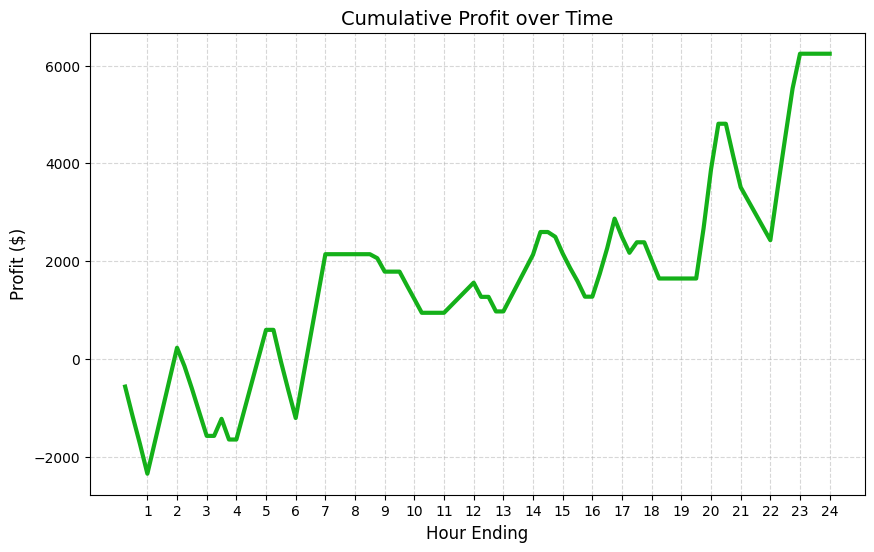

In [155]:
plt.figure(figsize=(10, 6))
plt.plot(profits, color="#14B019", linewidth=3)
plt.xlabel('Hour Ending', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.title('Cumulative Profit over Time', fontsize=14)
plt.xticks(range(3, 98, 4), labels=range(1, 25))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [163]:
rt_forecast, da_forecast = simulate_forecast_error(rt_prices[-1:], np.float64(0.2), da_prices[-1:], np.float64(0.2))

In [165]:
ampl.param['Pi_DA_E'] = da_forecast[-1]
ampl.param['Pi_RT_E'] = rt_forecast[-1]
ampl.solve()

pch_DA = [round(v, 1) for v in ampl.get_variable('pch_DA').to_dict().values()]
pg_DA = [round(v, 1) for v in ampl.get_variable('pg_DA').to_dict().values()]
pch_RT = [round(v,1) for v in ampl.get_variable('pch_RT').to_dict().values()]
pg_RT = [round(v,1) for v in ampl.get_variable('pg_RT').to_dict().values()]

actual_profit = calculate_cum_profit(list(dam_prices), list(rtm_prices), pch_DA, pg_DA, pch_RT, pg_RT)


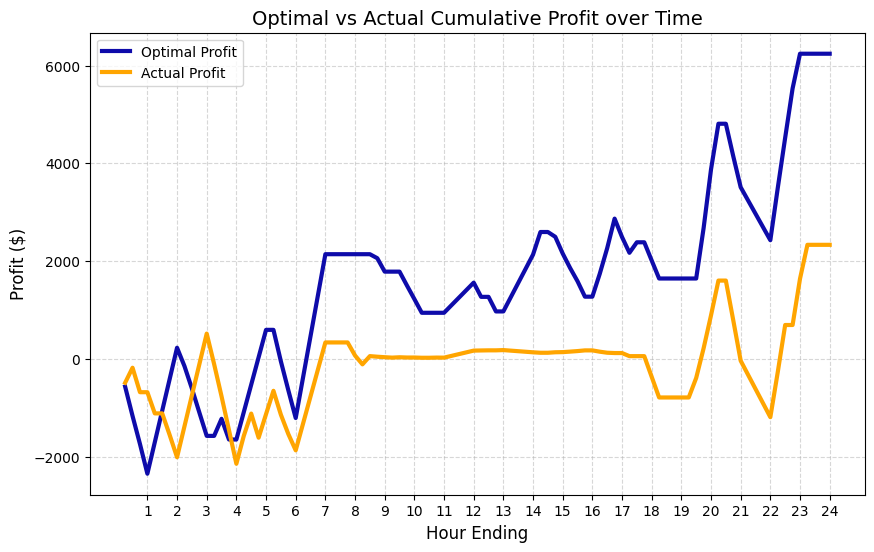

In [174]:
plt.figure(figsize=(10, 6))
plt.plot(profits, color="#0E0BAA", linewidth=3, label="Optimal Profit")
plt.plot(actual_profit, color='orange', linewidth=3, label="Actual Profit")

plt.xlabel('Hour Ending', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.title('Optimal vs Actual Cumulative Profit over Time', fontsize=14)
plt.legend()
plt.xticks(range(3, 98, 4), labels=range(1, 25))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [172]:
rt_forecast = rt_forecast[-1].values()
da_forecast = da_forecast[-1].values()

da_forecast = list(da_forecast) + list(da_forecast)[-1:]

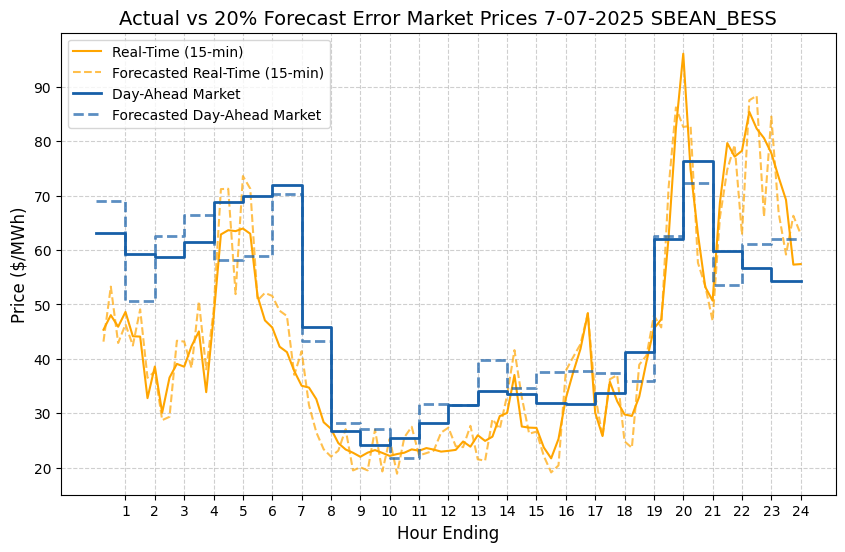

In [179]:
dam_prices = da_prices[-1].values()
rtm_prices = rt_prices[-1].values()

dam_prices = list(dam_prices) + list(dam_prices)[-1:]

plt.figure(figsize=(10, 6))

plt.plot(range(1, 97), rtm_prices, label='Real-Time (15-min)', 
         color='orange', alpha=1, linewidth=1.5)
plt.plot(range(1, 97), rt_forecast, label='Forecasted Real-Time (15-min)', 
         color='orange', alpha=0.7, linewidth=1.5, linestyle='--')

plt.step(range(0, 98, 4), dam_prices, where='post', label='Day-Ahead Market', linewidth=2, color="#165FA8", alpha=1)
plt.step(range(0, 98, 4), da_forecast, where='post', label='Forecasted Day-Ahead Market', linewidth=2, color="#165FA8", linestyle='--', alpha=0.7)


plt.xticks(range(4, 98, 4), labels=range(1, 25))
# 3. Formatting
plt.title('Actual vs 20% Forecast Error Market Prices 7-07-2025 SBEAN_BESS', fontsize=14)
plt.xlabel('Hour Ending', fontsize=12)
plt.ylabel('Price ($/MWh)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()

plt.show()

In [ ]:
optimal_profits = calculate_cum_profit(list(dam_prices), list(rtm_prices), pch_DA, pg_DA, pch_RT, pg_RT)
actual_profits = calculate_cum_profit(list(da_forecast), list(rt_forecast))

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(profits, color="#14B019", linewidth=3)
plt.xlabel('Hour Ending', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.title('Cumulative Profit over Time', fontsize=14)
plt.xticks(range(3, 98, 4), labels=range(1, 25))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()